In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the CLEANED data

In [2]:
df = pd.read_csv('processed_sleep_data.csv')

# Split into Features (X) and Target (y)

In [3]:
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Split into Train (80%) and Test (20%)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Class names mapping

In [5]:
class_names = ['Insomnia', 'None', 'Sleep Apnea']
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (299, 12)
Testing data shape: (75, 12)


# DECISION TREE


In [6]:
# Create and train Decision Tree Classifier
dt = DecisionTreeClassifier(
    max_depth=10,           # Prevent overfitting
    min_samples_split=5,    # Minimum samples to split a node
    min_samples_leaf=2,     # Minimum samples in leaf node
    random_state=42
)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
# Make predictions
y_pred_dt = dt.predict(X_test)

#  EVALUATION

In [8]:
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_names))

Decision Tree Accuracy: 0.9467

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.79      1.00      0.88        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       1.00      0.81      0.90        16

    accuracy                           0.95        75
   macro avg       0.93      0.93      0.92        75
weighted avg       0.96      0.95      0.95        75



# CONFUSION MATRIX

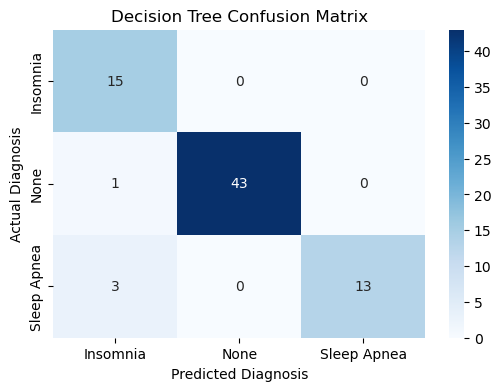

In [9]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

#  TREE VISUALIZATION

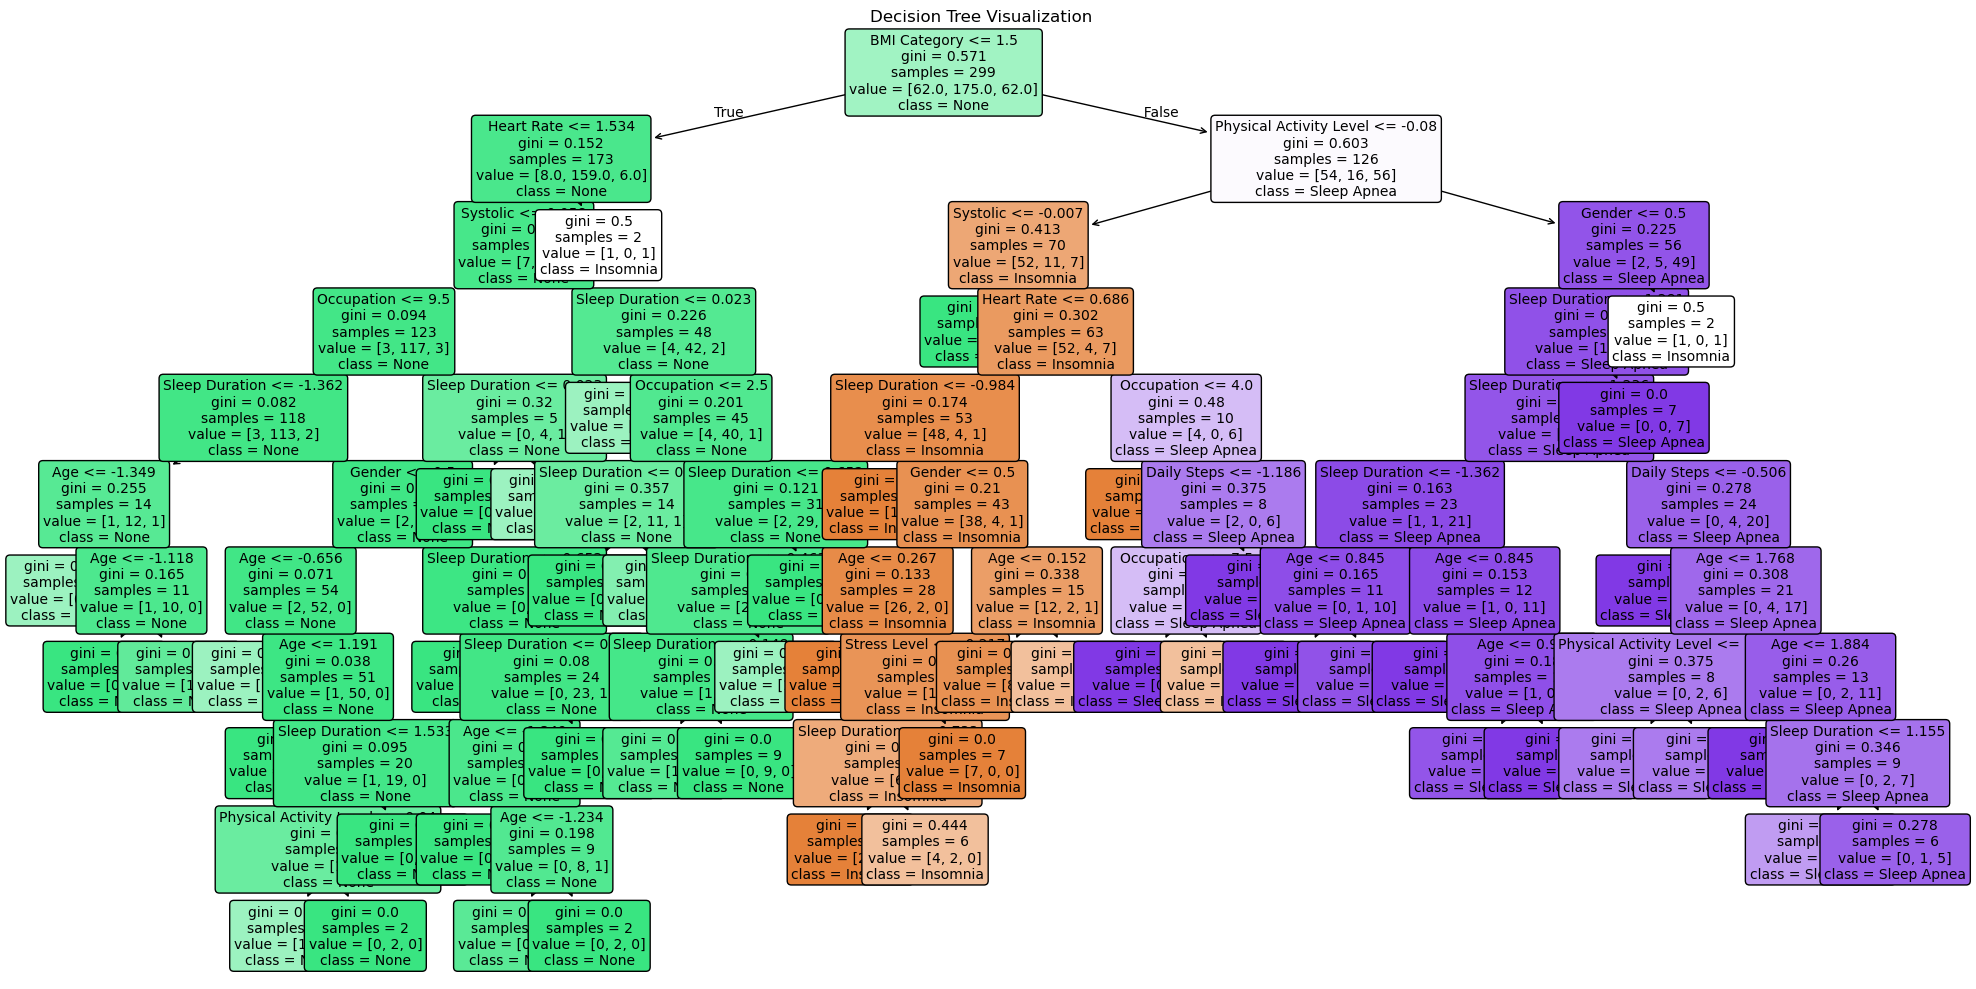

In [10]:
plt.figure(figsize=(20, 10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

#  FEATURE IMPORTANCE

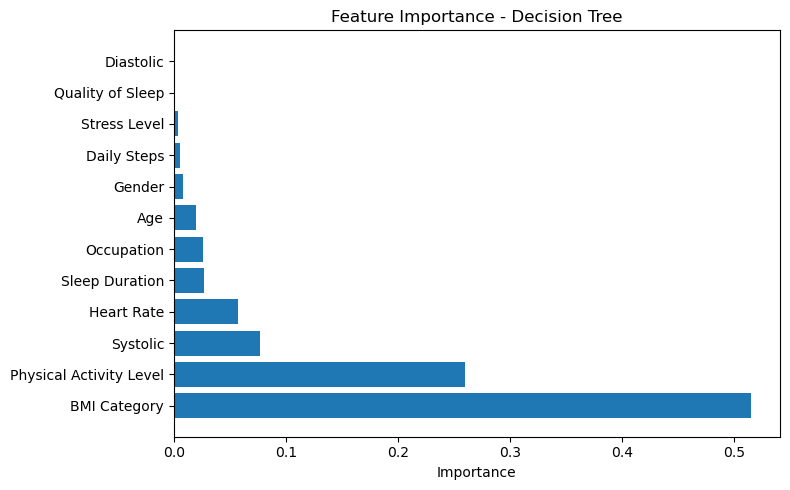


Feature Importance:
                    Feature  Importance
7              BMI Category    0.515451
5   Physical Activity Level    0.260238
10                 Systolic    0.076796
8                Heart Rate    0.057104
3            Sleep Duration    0.026951
2                Occupation    0.026092
1                       Age    0.020033
0                    Gender    0.007894
9               Daily Steps    0.005936
6              Stress Level    0.003505
4          Quality of Sleep    0.000000
11                Diastolic    0.000000


In [11]:
feature_importance = dt.feature_importances_
features = X.columns
imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(imp_df)

# TRAIN vs TEST ACCURACY

In [12]:

train_accuracy = accuracy_score(y_train, dt.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Overfitting Gap: {train_accuracy - test_accuracy:.4f}")


Train Accuracy: 0.9130
Test Accuracy: 0.9467
Overfitting Gap: -0.0336


# SAVE MODEL

In [13]:
# Export the trained model
joblib.dump(dt, 'decision_tree_model.pkl')
print("✓ Model saved as 'decision_tree_model.pkl'")

✓ Model saved as 'decision_tree_model.pkl'
